## Demo: Bilingual Course Description Similarity Detection

This notebook demonstrates the practical application of the evaluation pipeline developed in this thesis as a proof of concept for the AI Curriculum Tool. LaBSE is deployed with the operating threshold identified on the ICT dataset in Notebook 3, and the demo is built to mirror the end-user scenario: a curriculum designer provides a course description in Finnish or English, and the system searches a bilingual course database simultaneously in both languages to return ranked potential matches.

The indexed database for this demo is built from the BIT dataset introduced in Notebook 4, not from the ICT dataset used to train and evaluate the pipeline. This design choice is deliberate. Retrieving ICT courses from the ICT index would conflate demonstration with evaluation, because the queries would be lightly paraphrased versions of courses already in the database. Using BIT as the index keeps the demo honest: the retrieval system is being shown on data that was not used to select the model or calibrate the threshold.

Four queries illustrate the tool's behavior across typical operational scenarios, including an overlap warning zone between the equivalence threshold and a data-driven lower bound that flags potential partial matches for manual review.

### Imports and Setup

In [1]:
import sys
import time
import random
import warnings
from pathlib import Path
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import re
import unicodedata

from sentence_transformers import SentenceTransformer
from transformers import logging as hf_logging

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sentence_transformers")
hf_logging.set_verbosity_error()

print(f"Python               : {sys.version.split()[0]}")
print(f"torch                : {torch.__version__}")
print(f"sentence-transformers: {version('sentence-transformers')}")
print(f"numpy                : {np.__version__}")
print(f"pandas               : {pd.__version__}")

Python               : 3.10.20
torch                : 2.12.0.dev20260408+cu128
sentence-transformers: 5.3.0
numpy                : 2.2.6
pandas               : 2.3.3


### Project Paths

All paths are derived from the notebook's working directory, matching the pattern used across the pipeline.

In [2]:
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
EMBEDDINGS_DIR = DATA_DIR / "embeddings" / "ict"
RESULTS_DIR = DATA_DIR / "results"
SUMMARY_DIR = RESULTS_DIR / "summary_tables"
FIGURES_DIR = PROJECT_ROOT / "figures" / "main"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed    : {PROCESSED_DIR}")
print(f"Embeddings   : {EMBEDDINGS_DIR}")
print(f"Results      : {RESULTS_DIR}")
print(f"Summary      : {SUMMARY_DIR}")
print(f"Figures      : {FIGURES_DIR}")

Project root : c:\madee\thesis-project
Processed    : c:\madee\thesis-project\data\processed
Embeddings   : c:\madee\thesis-project\data\embeddings\ict
Results      : c:\madee\thesis-project\data\results
Summary      : c:\madee\thesis-project\data\results\summary_tables
Figures      : c:\madee\thesis-project\figures\main


### Loading Operating Threshold and Overlap Zone

Two decision boundaries are used by the retrieval function. The upper boundary is the equivalence threshold loaded from Notebook 3's cross-validation results. Above this score, two courses are classified as equivalent. The lower boundary marks the bottom of an overlap warning zone: scores between the two boundaries are flagged for manual review rather than returned as confident equivalence matches.

The lower boundary is derived from the ICT similarity-score distribution rather than hand-picked. It is set to the 5th percentile of similarity scores among positive pairs that the deployed system would classify as equivalent on ICT (score at or above the operating threshold). Scores below this value fall outside the practical range of genuine matches observed in the evaluation, and retrievals in that range are therefore treated as unlikely equivalence candidates.


In [3]:
# Upper boundary: the CV mean threshold from Notebook 3
ict_cv = pd.read_csv(SUMMARY_DIR / "cv_5fold_results.csv")
labse_cv_cfg1 = ict_cv[
    (ict_cv['model'] == 'labse') & (ict_cv['config'] == 'Outcomes (Raw)')
].iloc[0]
THRESHOLD = round(float(labse_cv_cfg1['threshold_mean']), 2)

# Lower boundary: 5th percentile of similarity scores among positive ICT pairs
# that the deployed threshold would actually accept, so the overlap zone
# reflects the range where genuine matches live in practice.
ict_df = pd.read_csv(PROCESSED_DIR / "dataset_preprocessed.csv")
ict_labels = ict_df['similarity_label'].values
fi_ict = np.load(EMBEDDINGS_DIR / 'labse_config1_fi.npy')
en_ict = np.load(EMBEDDINGS_DIR / 'labse_config1_en.npy')

# Sanity check the loaded embeddings
assert fi_ict.shape == (len(ict_df), 768), f"ICT fi shape {fi_ict.shape}"
assert en_ict.shape == (len(ict_df), 768), f"ICT en shape {en_ict.shape}"
assert np.allclose(np.linalg.norm(fi_ict, axis=1), 1.0, atol=1e-5)
assert np.allclose(np.linalg.norm(en_ict, axis=1), 1.0, atol=1e-5)

ict_sim = np.sum(fi_ict * en_ict, axis=1)
pos_scores = ict_sim[ict_labels == 1]
pos_above_threshold = pos_scores[pos_scores >= THRESHOLD]

if len(pos_above_threshold) >= 10:
    OVERLAP_LOWER = round(float(np.percentile(pos_above_threshold, 5)), 2)
else:
    # Small-sample fallback: use all positives
    OVERLAP_LOWER = round(float(np.percentile(pos_scores, 5)), 2)

# Safety clamp (should rarely trigger with the definition above)
if OVERLAP_LOWER >= THRESHOLD:
    OVERLAP_LOWER = round(THRESHOLD - 0.05, 2)

print(f"Equivalence threshold (upper): {THRESHOLD:.2f}  (loaded from CV results)")
print(f"Overlap zone lower bound     : {OVERLAP_LOWER:.2f}  "
      f"(5th percentile of positive pairs scored >= threshold on ICT)")
print(f"Overlap zone range           : [{OVERLAP_LOWER:.2f}, {THRESHOLD:.2f})")
print(f"\nEquivalent-class positive-pair similarity distribution on ICT:")
print(f"  min   = {pos_scores.min():.3f}")
print(f"  5%    = {np.percentile(pos_scores, 5):.3f}")
print(f"  median= {np.median(pos_scores):.3f}")
print(f"  max   = {pos_scores.max():.3f}")
print(f"  n_positives_above_threshold = {len(pos_above_threshold)} / {len(pos_scores)}")

Equivalence threshold (upper): 0.88  (loaded from CV results)
Overlap zone lower bound     : 0.83  (5th percentile of positive pairs scored >= threshold on ICT)
Overlap zone range           : [0.83, 0.88)

Equivalent-class positive-pair similarity distribution on ICT:
  min   = 0.871
  5%    = 0.900
  median= 0.930
  max   = 0.964
  n_positives_above_threshold = 75 / 77


### Loading LaBSE

LaBSE is loaded with `max_seq_length` set to 512, matching the configuration used in Notebook 2. The same L2-normalization helper used in Notebook 5 is reused here with embedded shape and norm assertions.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentenceTransformer('sentence-transformers/LaBSE', device=str(device))
model.max_seq_length = 512

print(f"LaBSE loaded on         : {device}")
print(f"Model max_seq_length    : {model.max_seq_length}")
print(f"Embedding dimensionality: {model.get_sentence_embedding_dimension()}")

def l2_normalize_verified(emb, name=""):
    assert emb.ndim == 2, f"{name}: expected 2D, got shape {emb.shape}"
    assert not np.isnan(emb).any(), f"{name}: NaN in embeddings"
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb = emb / np.clip(norms, a_min=1e-10, a_max=None)
    post = np.linalg.norm(emb, axis=1)
    assert np.allclose(post, 1.0, atol=1e-5), (
        f"{name}: L2 normalization failed, range [{post.min():.6f}, {post.max():.6f}]"
    )
    return emb

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

LaBSE loaded on         : cuda
Model max_seq_length    : 512
Embedding dimensionality: 768


### Query Cleaning

Queries are passed through the same cleaning function used in Notebook 1 before being encoded. This removes bullet-point artifacts, zero-width spaces, soft hyphens, and normalizes whitespace and Unicode. Without this step, triple-quoted query strings would carry leading and trailing newlines into the encoder, adding noise to the demonstration.

In [5]:
BULLET_CLASS = r'[\u2022\u2023\u25E6\u2043\u2219]'
INVISIBLE_CLASS = r'[\u200B\u200C\u200D\u00AD\uFEFF]'

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(BULLET_CLASS, '', text)
    text = re.sub(INVISIBLE_CLASS, '', text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Query cleaning function ready.")

Query cleaning function ready.


### Building the BIT Course Database

The BIT dataset from Notebook 4 is used as the indexed course database for this demo. Only rows corresponding to real courses are indexed. Constructed hard-negative pairs introduced during dataset construction, which carry synthetic identifiers beginning with `SYN_`, are filtered out because they do not represent real courses that a curriculum designer would ever see in deployment.

The Finnish and English outcomes fields are indexed separately, giving the retrieval function two parallel indexes to search. Embeddings are L2 normalized and verified immediately after encoding so that a later cosine computation reduces to a simple dot product on unit vectors.

In [6]:
bit_df = pd.read_csv(RAW_DIR / "verified_final_dataset_BIT.csv")

# Clean the fields we will index
for col in ('outcomes_fi', 'outcomes_en'):
    bit_df[col] = bit_df[col].apply(clean_text)

# Filter to real courses only. Prefer the pair_type column if present
# (consistent with the ICT convention), otherwise fall back to excluding
# course IDs prefixed with SYN_.
before_n = len(bit_df)

if 'pair_type' in bit_df.columns:
    bit_df = bit_df[bit_df['pair_type'] == 'real'].copy()
    filter_method = "pair_type == 'real'"
else:
    is_real = ~bit_df['course_id'].astype(str).str.startswith('SYN_')
    bit_df = bit_df[is_real].copy()
    filter_method = "course_id prefix != 'SYN_'"

after_n = len(bit_df)
print(f"Real-course filter ({filter_method}): {before_n} -> {after_n} rows")
assert after_n > 0, (
    "Filter removed every row; verify the BIT CSV's pair_type or course_id convention"
)

# Deduplicate by course_id to build the course database
courses = bit_df[['course_id', 'title_fi', 'title_en', 'outcomes_fi', 'outcomes_en']]\
    .drop_duplicates(subset='course_id').reset_index(drop=True)

assert courses['course_id'].is_unique
assert (courses['outcomes_fi'].str.len() > 0).all(), "empty outcomes_fi after cleaning"
assert (courses['outcomes_en'].str.len() > 0).all(), "empty outcomes_en after cleaning"

print(f"Course database: {len(courses)} real courses indexed in Finnish and English")

# Encode and L2 normalize both indexes
print("\nEncoding Finnish index...")
fi_db = l2_normalize_verified(
    model.encode(courses['outcomes_fi'].tolist(), batch_size=32,
                 show_progress_bar=False, convert_to_numpy=True),
    "Finnish index",
)
print("Encoding English index...")
en_db = l2_normalize_verified(
    model.encode(courses['outcomes_en'].tolist(), batch_size=32,
                 show_progress_bar=False, convert_to_numpy=True),
    "English index",
)

print(f"\nFinnish index: {fi_db.shape}")
print(f"English index: {en_db.shape}")

Real-course filter (pair_type == 'real'): 72 -> 36 rows
Course database: 36 real courses indexed in Finnish and English

Encoding Finnish index...
Encoding English index...

Finnish index: (36, 768)
English index: (36, 768)


### Retrieval Function

The retrieval function accepts any text input regardless of language, encodes it with LaBSE, and compares it simultaneously against both the Finnish and English indexes. For every indexed course, both the Finnish-side and English-side similarity scores are kept so that per-language confidence is visible to the user. Courses are sorted by the stronger of the two scores, and verdicts use three categories: equivalent (above the upper threshold), partial overlap (within the overlap zone), and no match (below the lower bound).

Each call reports the end-to-end wall time so that the retrieval latency is concretely demonstrated.

In [7]:
def classify_score(score, upper=THRESHOLD, lower=OVERLAP_LOWER):
    if score >= upper:
        return 'EQUIVALENT'
    if score >= lower:
        return 'PARTIAL OVERLAP'
    return 'NO MATCH'

def find_similar_courses(query_text, top_k=5,
                        upper=THRESHOLD, lower=OVERLAP_LOWER):
    t0 = time.perf_counter()

    clean_q = clean_text(query_text)
    q_emb = model.encode([clean_q], show_progress_bar=False, convert_to_numpy=True)[0]
    q_emb = q_emb / max(np.linalg.norm(q_emb), 1e-10)

    fi_scores = np.dot(fi_db, q_emb)
    en_scores = np.dot(en_db, q_emb)

    results = []
    for idx in range(len(courses)):
        fi_s = float(fi_scores[idx])
        en_s = float(en_scores[idx])
        max_s = max(fi_s, en_s)
        if max_s >= lower:
            results.append({
                'course_id'      : courses.iloc[idx]['course_id'],
                'title_fi'       : courses.iloc[idx]['title_fi'],
                'title_en'       : courses.iloc[idx]['title_en'],
                'fi_score'       : round(fi_s, 3),
                'en_score'       : round(en_s, 3),
                'max_score'      : round(max_s, 3),
                'matched_side'   : 'Finnish' if fi_s >= en_s else 'English',
                'verdict'        : classify_score(max_s, upper, lower),
            })

    results.sort(key=lambda r: r['max_score'], reverse=True)
    elapsed = time.perf_counter() - t0
    return results[:top_k], elapsed

def print_retrieval(query_text, results, elapsed):
    print("=" * 72)
    clean_q = clean_text(query_text)
    print(f"Query ({len(clean_q)} chars, {elapsed*1000:.1f} ms):")
    print(f"  {clean_q[:220]}")
    print("-" * 72)
    if not results:
        print("No courses found at or above the overlap zone lower bound.")
    else:
        for i, r in enumerate(results, 1):
            print(f"Rank {i}: [{r['verdict']}]  max_score={r['max_score']:.3f}  "
                  f"(fi={r['fi_score']:.3f}, en={r['en_score']:.3f})")
            print(f"  course_id : {r['course_id']}")
            print(f"  title_fi  : {r['title_fi']}")
            print(f"  title_en  : {r['title_en']}")
            print()
    print("=" * 72)
    print()

### Demo Queries

Four queries illustrate the retrieval system. The first query is a Finnish-language description of a course topic. The second is the English-language version of the same topic, which should retrieve the same course to demonstrate the language-agnostic nature of LaBSE. The third is a new course topic that does not exist in the BIT database, to demonstrate negative behavior. The fourth is a partial-overlap query designed to land in the overlap warning zone.

The queries are constructed to match BIT course topics, not ICT, because BIT is the indexed database. The queries themselves are new text and are not verbatim pulls from the indexed courses.

In [8]:
# Preview a few indexed BIT courses so the queries can target realistic topics
print("First 10 indexed BIT courses (for query design reference):\n")
for _, row in courses.head(10).iterrows():
    print(f"  {row['course_id']}: {row['title_en']} / {row['title_fi']}")

First 10 indexed BIT courses (for query design reference):

  HG00CF51: UX Design / UX Design
  HG00CF52: 2D Basics / 2D Basics
  HG00CQ39: Game Software Engineering / Game Software Engineering
  HT00BY31: Roles and Responsibilities in Esports Organization / Roles and Responsibilities in Esports Organization
  HG00CF57: Game Optimization and Testing / Game Optimization and Testing
  HG00CI50: Music and Sound for Games / Music and Sound for Games
  HG00CF56: Introduction to XR and Mobile Development in Game Engine / Introduction to XR and Mobile Development in Game Engine
  HG00CH08: Game Implementation and Modding / Game Implementation and Modding
  HG00CF48: Introduction to Game Graphics / Introduction to Game Graphics
  HG00BY32: Game Development with Yahaha / Game Development with Yahaha


In [9]:
# Query 1: Finnish input targeting a topic likely present in BIT ICT-adjacent courses
query_fi = (
    "Opiskelija ymmärtää tietojärjestelmien perusteet, liiketoimintaprosessit "
    "ja digitalisaation vaikutuksen organisaatioihin."
)

# Query 2: English version of the same topic
query_en = (
    "The student understands the fundamentals of information systems, "
    "business processes, and the impact of digitalization on organizations."
)

# Query 3: A topic deliberately outside any typical BIT course scope
query_new = (
    "The student understands the principles of quantum computing and can apply "
    "quantum algorithms to solve computational problems. The student is familiar "
    "with quantum error correction methods and quantum hardware limitations."
)

# Query 4: Partial-overlap query that shares topic with multiple courses
query_partial = (
    "The student understands the basics of software project management and "
    "can apply agile methodologies to small team projects."
)

print("QUERY 1: Finnish input (information systems and digitalization)")
results_1, t1 = find_similar_courses(query_fi)
print_retrieval(query_fi, results_1, t1)

print("QUERY 2: English input (same topic as Query 1, cross-lingual retrieval)")
results_2, t2 = find_similar_courses(query_en)
print_retrieval(query_en, results_2, t2)

print("QUERY 3: English input (unrelated topic, expected no match)")
results_3, t3 = find_similar_courses(query_new)
print_retrieval(query_new, results_3, t3)

print("QUERY 4: English input (partial-overlap expected)")
results_4, t4 = find_similar_courses(query_partial)
print_retrieval(query_partial, results_4, t4)

QUERY 1: Finnish input (information systems and digitalization)
Query (121 chars, 33.1 ms):
  Opiskelija ymmärtää tietojärjestelmien perusteet, liiketoimintaprosessit ja digitalisaation vaikutuksen organisaatioihin.
------------------------------------------------------------------------
No courses found at or above the overlap zone lower bound.

QUERY 2: English input (same topic as Query 1, cross-lingual retrieval)
Query (135 chars, 15.8 ms):
  The student understands the fundamentals of information systems, business processes, and the impact of digitalization on organizations.
------------------------------------------------------------------------
No courses found at or above the overlap zone lower bound.

QUERY 3: English input (unrelated topic, expected no match)
Query (221 chars, 14.9 ms):
  The student understands the principles of quantum computing and can apply quantum algorithms to solve computational problems. The student is familiar with quantum error correction methods an

### Visualising Retrieval Confidence Across the Four Queries

The chart below shows the top similarity score returned for each query alongside the equivalence threshold (upper boundary) and the overlap zone (shaded band). This is how the AI Curriculum Tool would present a retrieval summary to a curriculum designer.

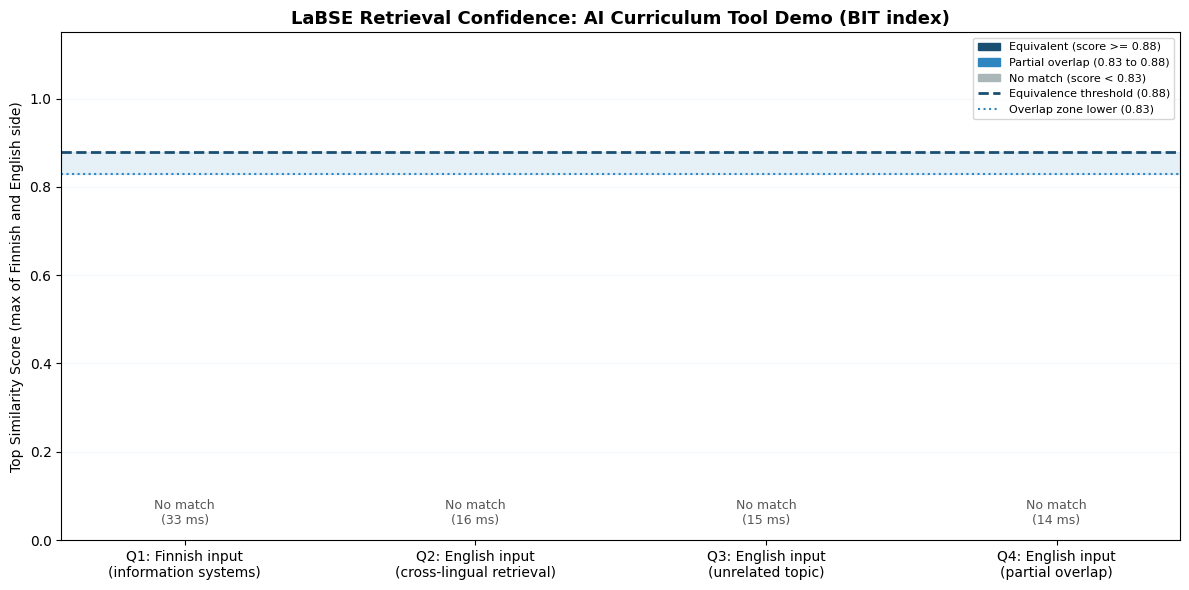

Plot saved: c:\madee\thesis-project\figures\main\demo_retrieval.png


In [10]:
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'
NEGATIVE = '#AAB7B8'
GRID_COLOR = '#D6EAF8'

labels = [
    'Q1: Finnish input\n(information systems)',
    'Q2: English input\n(cross-lingual retrieval)',
    'Q3: English input\n(unrelated topic)',
    'Q4: English input\n(partial overlap)',
]
best_scores = [
    results_1[0]['max_score'] if results_1 else 0.0,
    results_2[0]['max_score'] if results_2 else 0.0,
    results_3[0]['max_score'] if results_3 else 0.0,
    results_4[0]['max_score'] if results_4 else 0.0,
]
elapsed_ms = [t1 * 1000, t2 * 1000, t3 * 1000, t4 * 1000]

bar_colors = []
for s in best_scores:
    if s >= THRESHOLD:
        bar_colors.append(PRIMARY)
    elif s >= OVERLAP_LOWER:
        bar_colors.append(SECONDARY)
    else:
        bar_colors.append(NEGATIVE)

fig, ax = plt.subplots(figsize=(12, 6))

ax.axhspan(OVERLAP_LOWER, THRESHOLD, alpha=0.12, color=SECONDARY, zorder=0)
ax.axhline(y=THRESHOLD, color=PRIMARY, linestyle='--', linewidth=2, zorder=1)
ax.axhline(y=OVERLAP_LOWER, color=SECONDARY, linestyle=':', linewidth=1.5, zorder=1)

bars = ax.bar(labels, best_scores, color=bar_colors,
              edgecolor='white', linewidth=0.8, width=0.5, zorder=2)

for bar, score, ms in zip(bars, best_scores, elapsed_ms):
    if score > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f"{score:.3f}\n({ms:.0f} ms)",
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, 0.03,
                f"No match\n({ms:.0f} ms)",
                ha='center', va='bottom', fontsize=9, color='#555555')

ax.legend(handles=[
    mpatches.Patch(color=PRIMARY, label=f'Equivalent (score >= {THRESHOLD:.2f})'),
    mpatches.Patch(color=SECONDARY, label=f'Partial overlap ({OVERLAP_LOWER:.2f} to {THRESHOLD:.2f})'),
    mpatches.Patch(color=NEGATIVE, label=f'No match (score < {OVERLAP_LOWER:.2f})'),
    plt.Line2D([0], [0], color=PRIMARY, linestyle='--', linewidth=2,
               label=f'Equivalence threshold ({THRESHOLD:.2f})'),
    plt.Line2D([0], [0], color=SECONDARY, linestyle=':', linewidth=1.5,
               label=f'Overlap zone lower ({OVERLAP_LOWER:.2f})'),
], fontsize=8, loc='upper right')

ax.set_title('LaBSE Retrieval Confidence: AI Curriculum Tool Demo (BIT index)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Top Similarity Score (max of Finnish and English side)')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = FIGURES_DIR / 'demo_retrieval.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

### Notebook Summary

This notebook demonstrated the practical application of the thesis pipeline as a proof of concept for the AI Curriculum Tool. LaBSE was deployed as a cross-lingual retrieval system that accepts course description input in Finnish or English, encodes the query, and searches the indexed BIT course database simultaneously in both languages. Four queries illustrated the four operational cases: same-language equivalence retrieval, cross-lingual equivalence retrieval, unrelated-topic rejection, and partial-overlap flagging in the data-driven overlap zone.

Both decision boundaries used by the retrieval function are data-driven rather than hand-picked. The upper boundary is the mean cross-validation threshold from Notebook 3, and the lower boundary is the 5th percentile of similarity scores among positive ICT pairs that the deployed threshold would actually accept (score at or above the equivalence threshold). Defining the lower boundary this way restricts it to the range where the system would already treat a pair as equivalent, producing an overlap zone that reflects practical decision uncertainty rather than the full positive-score distribution.

### Practical Deployment Considerations

Three considerations matter for moving from this demonstration toward real deployment in the AI Curriculum Tool.

First, scale. This demo indexes the BIT course set. Real JAMK curriculum management covers thousands of courses across all degree programmes. LaBSE encoding runs at a few milliseconds per query on commodity hardware once the index is precomputed, and the precomputed index is small (under 10 MB per thousand courses at 768 float32 dimensions), so the approach scales to the full institutional catalogue without architectural changes. A pilot at the full-catalogue scale should nonetheless measure end-to-end latency and memory footprint under realistic load before production deployment.

Second, field robustness. The demo uses the outcomes field only, consistent with the Notebook 3 finding that outcomes alone provide the strongest discriminative signal. A real deployment should handle courses where the outcomes field is missing, sparse, or under translation, and fall back gracefully to contents or assessment fields rather than failing silently. This fallback behaviour is not implemented in this demo and should be addressed before pilot deployment.

Third, overlap-zone policy. The overlap zone between the lower bound and the equivalence threshold is the region where human review adds the most value, because the model's confidence is intermediate. A concrete policy should specify what the tool shows the curriculum designer for these cases, how the designer's verdict is captured back into the system, and whether the zone boundaries should be re-calibrated periodically as new courses are added to the catalogue.

On the evidence of this demo plus the generalisation results in Notebook 4, the pipeline is suitable for a pilot test of the AI Curriculum Tool at scale. A broader deployment across institutions beyond JAMK would require validation on data from those institutions, because terminology, schema, and curriculum structure all vary.